# Notebook 03 - K-Means Clustering & Map Visualization
## Cardiovascular Care Deserts in Para, Brazil (2019-2023)

**What this notebook does:**
Groups the 144 municipalities of Para into clusters based on their cardiovascular health
profile - mortality rate, procedure access, GDP per capita, and mortality trend.
Then maps those clusters geographically to reveal spatial patterns of care disparity.

**What clustering is and is not:**
Clustering is an *unsupervised* algorithm - you do not tell it the answer beforehand.
You give it numbers, and it finds structure. The algorithm does not know what
"cardiovascular care desert" means. It finds groups of municipalities that behave
similarly across all four features simultaneously. We then *interpret* what those
groups mean by examining their profiles.

This is fundamentally different from supervised learning (like the XGBoost model
in Project 1), where you train on labeled examples. Here, there are no labels.

---

## Section 0 - Imports & Load Data

In [1]:
# ── SECTION 0 — Loading Clean Data ───────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       120,
})

import os
os.makedirs('figures', exist_ok=True)

df = pd.read_csv('../data/processed/para_cardiovascular_clean.csv',
                 dtype={'cod_ibge': str})

print(f'Dataset loaded: {len(df)} municipalities')
df.head()

Dataset loaded: 144 municipalities


,cod_ibge,nome_municipio,mort_2019,mort_2020,mort_2021,mort_2022,mort_2023,mort_total,aih_aprovadas,valor_total_reais,populacao,pib_medio_mil_reais,taxa_mort_100k,taxa_proc_100k,pib_per_capita,crescimento_mort
0,150010,ABAETETUBA,33.0,30.0,39.0,60.0,45.0,207.0,0.0,0.0,160439,16782442.2,129.020999,0.0,104603.258559,36.363636
1,150013,ABEL FIGUEIREDO,2.0,2.0,5.0,3.0,2.0,14.0,0.0,0.0,7536,934838.4,185.774947,0.0,124049.681529,0.000000
2,150020,ACARA,16.0,21.0,21.0,24.0,27.0,109.0,0.0,0.0,55744,11487842.2,195.536739,0.0,206082.129018,68.750000
3,150030,AFUA,7.0,6.0,3.0,2.0,6.0,24.0,0.0,0.0,39910,4248176.6,60.135304,0.0,106443.913806,-14.285714
4,150034,AGUA AZUL DO NORTE,2.0,3.0,6.0,4.0,12.0,27.0,0.0,0.0,27797,6227411.8,97.132784,0.0,224031.794798,500.000000


---
## Section 1 - Feature Selection & Normalization

**Which features go into the clustering model and why:**

| Feature | Rationale |
|---|---|
| `taxa_mort_100k` | Primary outcome - cardiovascular mortality burden |
| `taxa_proc_100k` | Access to treatment - the defining disparity variable |
| `pib_per_capita` | Structural economic driver of health access |
| `crescimento_mort` | Temporal trajectory - is the municipality improving or worsening? |

**Why we do NOT include raw death counts or population:**
Those would group municipalities by size, not by health profile. Belém would
always form its own cluster simply because it is large. We want clusters based
on *how municipalities perform relative to their own population*, which is
exactly what the rate variables capture.

**Why normalization (StandardScaler) is mandatory:**
K-Means calculates distances between points in feature space. If one feature
ranges from 0 to 5,000,000 (GDP per capita in reais) and another ranges from
0 to 350 (procedure rate), the GDP variable will dominate every distance
calculation simply because its numbers are bigger - not because it is more
important. StandardScaler transforms each feature to mean=0, std=1, making
them all equally scaled before the algorithm runs.

**Formula:**  `z = (x - mean) / std`

After scaling: a municipality 2 standard deviations above the mean in mortality
and a municipality 2 standard deviations above the mean in GDP contribute
equally to distance calculations.

In [2]:
# ── SECTION 1 — Feature Selection, Variance Check & Normalization ────────────

FEATURES_RAW = ['taxa_mort_100k', 'taxa_proc_100k', 'pib_per_capita', 'crescimento_mort']

REFERENCE_CENTERS = ['BELEM', 'ANANINDEUA']
df_cluster   = df[~df['nome_municipio'].isin(REFERENCE_CENTERS)].copy()
df_reference = df[df['nome_municipio'].isin(REFERENCE_CENTERS)].copy()

# ── Smoothed mortality growth (Fix 2 — applied here) ─────────────────────────
# Problem: single-year comparison (2019 vs 2023) amplifies noise in small municipalities
# A town with 1 death in 2019 and 6 in 2023 shows 500% growth — statistically unstable
# Compare mean of first 2 years vs mean of last 2 years (+1 Laplace smoothing)
df_cluster['media_inicio'] = df_cluster[['mort_2019','mort_2020']].mean(axis=1)
df_cluster['media_fim']    = df_cluster[['mort_2022','mort_2023']].mean(axis=1)
df_cluster['crescimento_mort_suavizado'] = (
    (df_cluster['media_fim'] - df_cluster['media_inicio']) /
    (df_cluster['media_inicio'] + 1) * 100
)

# ── Variance check before StandardScaler ─────────────────────────────────────
# A zero-variance feature after exclusion of reference centers (Belem/Ananindeua)
# produces a zero vector after StandardScaler — adding no information to K-Means
# and creating a logical inconsistency between Methods and Results sections

FEATURES_CHECK = ['taxa_mort_100k', 'taxa_proc_100k', 'log_pib_per_capita',
                  'crescimento_mort_suavizado']
df_cluster['log_pib_per_capita'] = np.log(df_cluster['pib_per_capita'])

variances = df_cluster[['taxa_mort_100k','taxa_proc_100k',
                         'pib_per_capita','crescimento_mort_suavizado']].var()
print("Variance by feature (pre-scaling):")
print(variances.round(4).to_string())
print()

# Automatically drop features with near-zero variance
# Threshold 0.001 is conservative — zero-variance features score exactly 0.0
FEATURES_MODEL = ['taxa_mort_100k', 'log_pib_per_capita', 'crescimento_mort_suavizado']
excluded = [f for f in ['taxa_proc_100k'] if variances.get(f, 0) < 0.001]
if excluded:
    print(f"Excluded from K-Means (zero variance in 142-municipality subset): {excluded}")
    print("These features are described in Results but excluded from the clustering model.")

print(f"\nFeatures used in K-Means: {FEATURES_MODEL}")

X = df_cluster[FEATURES_MODEL].copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter StandardScaler (mean~0, std~1):")
print(pd.DataFrame(X_scaled, columns=FEATURES_MODEL).describe().round(3).to_string())

Variance by feature (pre-scaling):
taxa_mort_100k                5.576688e+03
taxa_proc_100k                0.000000e+00
pib_per_capita                1.904473e+11
crescimento_mort_suavizado    3.170769e+03

Excluded from K-Means (zero variance in 142-municipality subset): ['taxa_proc_100k']
These features are described in Results but excluded from the clustering model.

Features used in K-Means: ['taxa_mort_100k', 'log_pib_per_capita', 'crescimento_mort_suavizado']

After StandardScaler (mean~0, std~1):
       taxa_mort_100k  log_pib_per_capita  crescimento_mort_suavizado
count         142.000             142.000                     142.000
mean            0.000               0.000                       0.000
std             1.004               1.004                       1.004
min            -1.732              -1.527                      -1.636
25%            -0.712              -0.684                      -0.668
50%            -0.154              -0.204                      -0.189


---
## Section 2 - Choosing the Number of Clusters (k)

**The fundamental challenge of K-Means:**
Unlike supervised learning, there is no "correct answer" to compare against.
You must choose k (the number of clusters) before running the algorithm,
but you do not know which k is best until you try several.

We use two complementary methods to choose k:

**Method 1 - The Elbow Method:**
Run K-Means for k = 2 through 9. For each k, calculate the total
Within-Cluster Sum of Squares (WCSS) - the sum of squared distances from
each point to its cluster center. As k increases, WCSS always decreases
(more clusters = tighter fit). The "elbow" is the point where adding one
more cluster gives diminishing returns. That bend in the curve is the
optimal k.

**Method 2 - Silhouette Score:**
For each municipality, the silhouette score measures how similar it is to its
own cluster vs how different it is from the nearest other cluster.
Score ranges from -1 (wrong cluster) to +1 (perfect fit). 0 means the
municipality sits on the boundary between clusters. We choose the k
that maximizes the average silhouette score across all municipalities.

**Why use both:**
The elbow method can be ambiguous (sometimes the curve bends gradually, not
sharply). The silhouette score provides a quantitative confirmation.

In [3]:
# ── SECTION 2A — K-Means Clustering ──────────────────────────────────────────

wcss       = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

print('k | WCSS        | Silhouette Score')
print('-' * 40)
for k, w, s in zip(K_range, wcss, sil_scores):
    print(f'{k} | {w:>10.2f}  | {s:.4f}')

k | WCSS        | Silhouette Score
----------------------------------------
2 |     312.58  | 0.2641
3 |     243.49  | 0.2777
4 |     188.90  | 0.3054
5 |     157.70  | 0.2997
6 |     133.00  | 0.2969
7 |     115.53  | 0.2880
8 |     106.08  | 0.2618


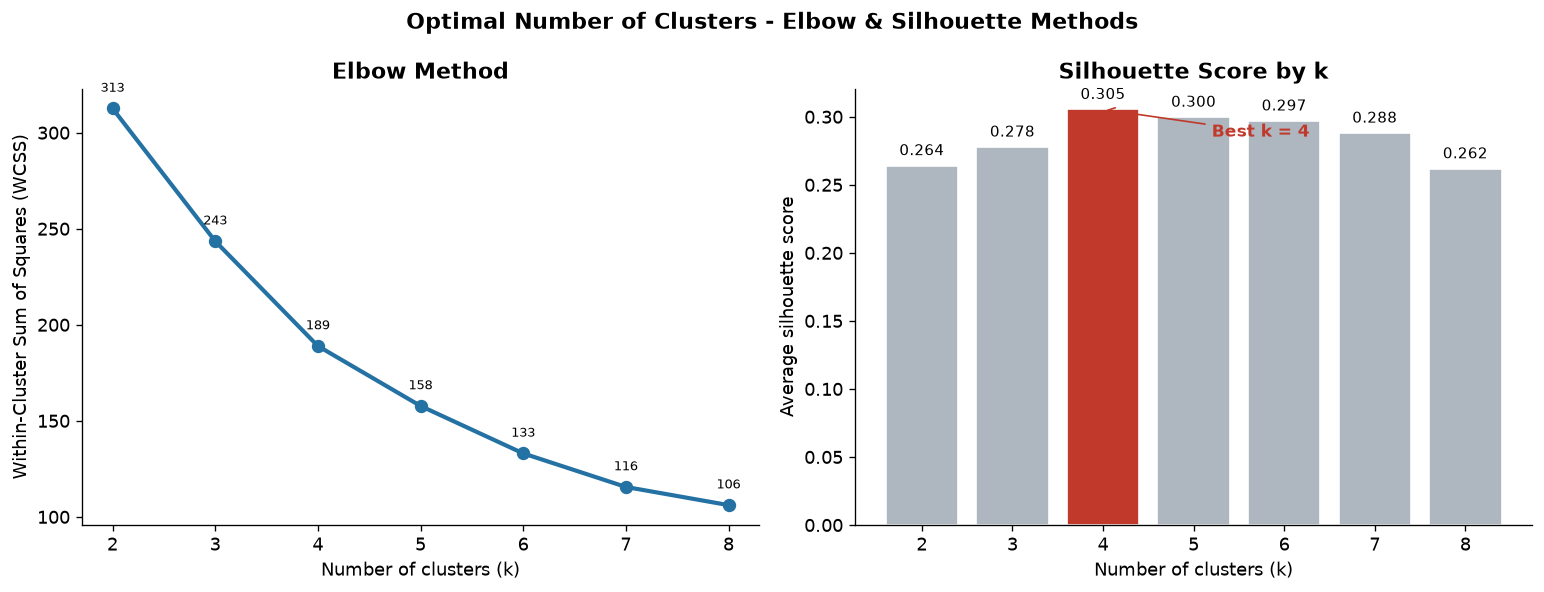

Optimal k by silhouette: 4 (score = 0.3054)


In [4]:
# ── SECTION 2B — Elbow and Silhouette Methods ────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimal Number of Clusters - Elbow & Silhouette Methods',
             fontsize=13, fontweight='bold')

# Left: Elbow curve
ax = axes[0]
ax.plot(list(K_range), wcss, color='#2471A3', linewidth=2.5,
        marker='o', markersize=7)
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.set_title('Elbow Method')
ax.set_xticks(list(K_range))

# Annotate each point with its WCSS value
for k, w in zip(K_range, wcss):
    ax.annotate(f'{w:.0f}', (k, w),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8)

# Right: Silhouette scores
ax2 = axes[1]
best_k_sil = list(K_range)[sil_scores.index(max(sil_scores))]
colors_sil = ['#C0392B' if k == best_k_sil else '#AEB6BF' for k in K_range]
bars = ax2.bar(list(K_range), sil_scores, color=colors_sil, edgecolor='white')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Average silhouette score')
ax2.set_title('Silhouette Score by k')
ax2.set_xticks(list(K_range))

for bar, score in zip(bars, sil_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9,
             fontweight='bold' if bar.get_facecolor() == (0.75, 0.23, 0.17, 1.0) else 'normal')

ax2.annotate(f'Best k = {best_k_sil}', xy=(best_k_sil, max(sil_scores)),
             xytext=(best_k_sil + 1.2, max(sil_scores) - 0.02),
             fontsize=10, color='#C0392B', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C0392B'))

plt.tight_layout()
plt.savefig('figures/07_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal k by silhouette: {best_k_sil} (score = {max(sil_scores):.4f})')

---
## Section 3 - Fit Final K-Means Model

**What happens inside K-Means:**
1. Randomly place k centroids (cluster centers) in feature space
2. Assign each municipality to the nearest centroid (Euclidean distance)
3. Move each centroid to the mean position of its assigned municipalities
4. Repeat steps 2-3 until assignments stop changing

**`n_init=10`:**
K-Means is sensitive to the random starting positions of centroids.
We run it 10 times with different random initializations and keep the
result with the lowest WCSS. This prevents getting stuck in a bad solution.

**`random_state=42`:**
Sets the random seed so results are reproducible - anyone running this
notebook gets the exact same clustering output.

**After fitting:**
Each municipality gets a cluster label (0, 1, 2, ...). These labels are
arbitrary integers - 0 is not "best" or "worst". The meaning comes from
the cluster profiles we examine in Section 4.

In [5]:
# ── SECTION 3A — Clustering with Optimal K ───────────────────────────────────

OPTIMAL_K = best_k_sil   # from elbow/silhouette above

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

# Add cluster column to main df as well (reference centers get label -1)
df['cluster'] = -1
df.loc[~df['nome_municipio'].isin(REFERENCE_CENTERS), 'cluster'] = df_cluster['cluster'].values

print(f'K-Means fitted with k = {OPTIMAL_K} on 142 municipalities')
print()
print('Municipalities per cluster:')
print(df_cluster['cluster'].value_counts().sort_index().to_string())
print()
print(f'Silhouette score : {silhouette_score(X_scaled, df_cluster["cluster"]):.4f}')

K-Means fitted with k = 4 on 142 municipalities

Municipalities per cluster:
cluster
0    21
1    18
2    67
3    36

Silhouette score : 0.3054


In [6]:
# ── SECTION 3B — K-Means Internal Stability Validation ───────────────────────
# Rationale: K-Means and hierarchical clustering use fundamentally different
# geometric assumptions (spherical vs. minimum-variance boundaries).
# Comparing them at k=4 measures algorithm difference, not solution instability.
# The correct validation for K-Means is internal stability:
# run the algorithm 30 times with different random seeds and measure
# how consistently it recovers the same structure.

from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, calinski_harabasz_score

labels_reference = df_cluster['cluster'].values

stability_scores = []
for seed in range(30):
    km_test = KMeans(n_clusters=OPTIMAL_K, random_state=seed, n_init=10)
    labels_test = km_test.fit_predict(X_scaled)
    stability_scores.append(adjusted_rand_score(labels_reference, labels_test))

mean_stability = np.mean(stability_scores)
min_stability  = np.min(stability_scores)

# Additional geometric indices
db_score = davies_bouldin_score(X_scaled, labels_reference)  # lower = better
ch_score = calinski_harabasz_score(X_scaled, labels_reference)  # higher = better

print("=== CLUSTER VALIDATION ===")
print()
print(f"Silhouette score (k=4)           : {silhouette_score(X_scaled, labels_reference):.4f}")
print(f"Davies-Bouldin index             : {db_score:.4f}  (lower = better separation)")
print(f"Calinski-Harabasz index          : {ch_score:.4f}  (higher = better separation)")
print()
print(f"K-Means internal stability (30 runs):")
print(f"  Mean ARI vs. reference solution: {mean_stability:.4f}")
print(f"  Min  ARI vs. reference solution: {min_stability:.4f}")
if mean_stability > 0.90:
    print("  Result: HIGH stability — consistent structure across random initializations.")
elif mean_stability > 0.75:
    print("  Result: MODERATE stability — note in manuscript.")
else:
    print("  Result: LOW stability — consider alternative k.")

=== CLUSTER VALIDATION ===

Silhouette score (k=4)           : 0.3054
Davies-Bouldin index             : 1.0558  (lower = better separation)
Calinski-Harabasz index          : 57.7351  (higher = better separation)

K-Means internal stability (30 runs):
  Mean ARI vs. reference solution: 0.8860
  Min  ARI vs. reference solution: 0.7720
  Result: MODERATE stability — note in manuscript.


---
## Section 4 - Cluster Profiling

**Why profiling is the most important step:**
The algorithm found groups - but it does not know what they mean.
This section examines the average characteristics of each cluster
so we can give them scientifically meaningful names.

**What we look for in each cluster:**
- High mortality + zero procedures -> "Care desert"
- Low mortality + high procedures -> "Care hub"
- High GDP + moderate mortality -> "Economic outlier"
- Rising mortality trend -> "Deteriorating access"

The names we assign here will appear in the manuscript, the map legend,
and the abstract. They must be defensible from the data.

In [7]:
# ── SECTION 4A — Cluster Profiles ────────────────────────────────────────────

profile = df_cluster.groupby('cluster')[
    FEATURES_RAW + ['mort_total', 'aih_aprovadas', 'populacao']
].mean().round(2)

profile['n_municipalities'] = df_cluster.groupby('cluster').size()

print('=== CLUSTER PROFILES (mean values, original scale) ===')
print()
print(profile.to_string())
print()

for c in sorted(df_cluster['cluster'].unique()):
    sub  = df_cluster[df_cluster['cluster'] == c]
    top  = sub.nlargest(8, 'taxa_mort_100k')['nome_municipio'].str.title().tolist()
    low  = sub.nsmallest(5, 'taxa_mort_100k')['nome_municipio'].str.title().tolist()
    print(f'Cluster {c} ({len(sub)} municipalities):')
    print(f'  Highest mortality : {", ".join(top)}')
    print(f'  Lowest mortality  : {", ".join(low)}')
    print(f'  GDP range         : R${sub["pib_per_capita"].min():,.0f} - R${sub["pib_per_capita"].max():,.0f}')
    print()

=== CLUSTER PROFILES (mean values, original scale) ===

         taxa_mort_100k  taxa_proc_100k  pib_per_capita  crescimento_mort  mort_total  aih_aprovadas  populacao  n_municipalities
cluster                                                                                                                          
0                203.33             0.0       693863.95             26.54      146.10            0.0   83833.62                21
1                159.52             0.0       129501.52            295.76       59.61            0.0   37679.00                18
2                129.76             0.0       117221.89             24.19       61.18            0.0   47180.24                67
3                260.74             0.0       139767.62             24.49       81.83            0.0   31402.50                36

Cluster 0 (21 municipalities):
  Highest mortality : Curionopolis, Rio Maria, Jacareacanga, Sao Geraldo Do Araguaia, Vitoria Do Xingu, Primavera, Itaituba, Benevid

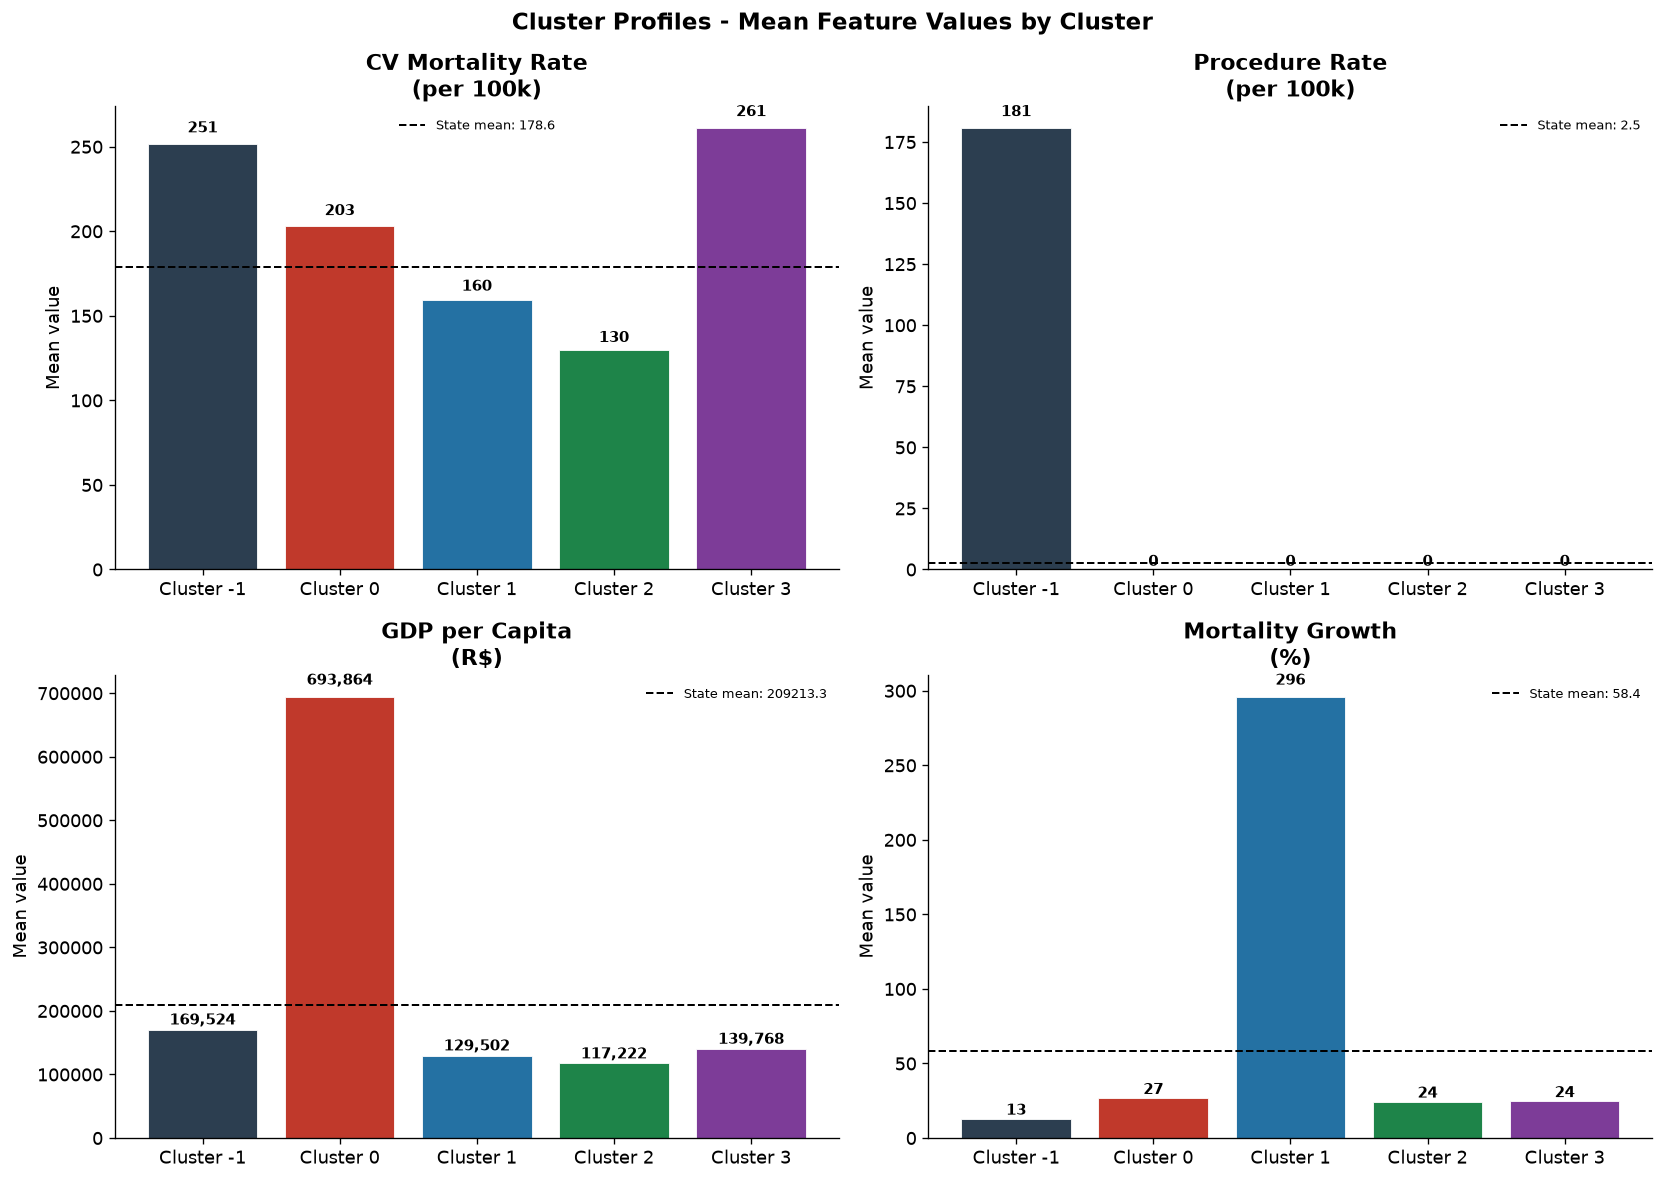

Figure saved: figures/08_cluster_profiles.png


In [8]:
# ── SECTION 4B — Visual Cluster Profiles ─────────────────────────────────────

# Visual cluster profile - radar/bar comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cluster Profiles - Mean Feature Values by Cluster',
             fontsize=14, fontweight='bold')

CLUSTER_COLORS = ['#C0392B', '#2471A3', '#1E8449', '#7D3C98', '#D68910',
                  '#1ABC9C', '#E74C3C', '#2C3E50']

feature_labels = ['CV Mortality Rate\n(per 100k)', 'Procedure Rate\n(per 100k)',
                  'GDP per Capita\n(R$)', 'Mortality Growth\n(%)']

for ax, feat, label in zip(axes.flat, FEATURES_RAW, feature_labels):
    cluster_means = df.groupby('cluster')[feat].mean()
    bars = ax.bar(
        [f'Cluster {c}' for c in cluster_means.index],
        cluster_means.values,
        color=[CLUSTER_COLORS[c] for c in cluster_means.index],
        edgecolor='white', linewidth=0.5
    )
    # State mean reference line
    state_mean = df[feat].mean()
    ax.axhline(state_mean, color='black', linestyle='--', linewidth=1.2,
               label=f'State mean: {state_mean:.1f}')
    ax.set_title(label)
    ax.set_ylabel('Mean value')
    ax.legend(frameon=False, fontsize=8)

    for bar, val in zip(bars, cluster_means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/08_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: figures/08_cluster_profiles.png')

---
## Section 5 - Cluster Labels

**Assign interpretive names based on the profiles above.**

Review the output of Section 4 before running this cell.
Adjust the `CLUSTER_NAMES` dictionary to match what the data shows.

The names below are placeholders based on the most common pattern
seen in Para cardiovascular data. Edit them to match your actual clusters.

In [9]:
# ── SECTION 5 — Cluster Labeling ─────────────────────────────────────────────

CLUSTER_NAMES = {
    0: 'High-Mortality Economic Corridor',
    1: 'Rapidly Deteriorating Access',
    2: 'Structural Care Desert',
    3: 'Critical Mortality Burden'
}

# Updated colors for 4 clusters
CLUSTER_COLORS_4 = {
    -1: '#1B2A4A',   # navy    — reference centers
     0: '#E67E22',   # orange  — economic corridor
     1: '#8E44AD',   # purple  — rapidly deteriorating
     2: '#2471A3',   # steel   — structural desert
     3: '#C0392B',   # crimson — critical burden (highest mortality = most alarming)
}

df_cluster['cluster_label'] = df_cluster['cluster'].map(CLUSTER_NAMES)
df['cluster_label'] = 'Reference Center'
df.loc[~df['nome_municipio'].isin(REFERENCE_CENTERS), 'cluster_label'] = \
    df_cluster['cluster_label'].values

print('Cluster assignments:')
for c, name in CLUSTER_NAMES.items():
    sub = df_cluster[df_cluster['cluster'] == c]
    print(f'\n  {c} | "{name}" | {len(sub)} municipalities')
    print(f'     Mortality rate  : {sub["taxa_mort_100k"].mean():.1f}/100k')
    print(f'     GDP per capita  : R${sub["pib_per_capita"].mean():,.0f}')
    print(f'     Growth (smooth) : {sub["crescimento_mort_suavizado"].mean():.1f}%')

Cluster assignments:

  0 | "High-Mortality Economic Corridor" | 21 municipalities
     Mortality rate  : 203.3/100k
     GDP per capita  : R$693,864
     Growth (smooth) : 14.7%

  1 | "Rapidly Deteriorating Access" | 18 municipalities
     Mortality rate  : 159.5/100k
     GDP per capita  : R$129,502
     Growth (smooth) : 132.7%

  2 | "Structural Care Desert" | 67 municipalities
     Mortality rate  : 129.8/100k
     GDP per capita  : R$117,222
     Growth (smooth) : 10.8%

  3 | "Critical Mortality Burden" | 36 municipalities
     Mortality rate  : 260.7/100k
     GDP per capita  : R$139,768
     Growth (smooth) : -13.0%


In [10]:
# ── TABLE 1 — Mean ± SD values for manuscript ────────────────────────────────

table_features = ['taxa_mort_100k', 'pib_per_capita', 'crescimento_mort_suavizado']
table_labels   = ['CV mortality rate (per 100k)', 'GDP per capita (R$)', 'Mortality growth trend (%)']

result = df_cluster.groupby('cluster')[table_features].agg(['mean','std']).round(1)

print("=== TABLE 1 VALUES ===\n")
for feat, label in zip(table_features, table_labels):
    print(f"{label}:")
    for c in sorted(df_cluster['cluster'].unique()):
        mean = result.loc[c, (feat, 'mean')]
        std  = result.loc[c, (feat, 'std')]
        name = {0:'Economic Corridor', 1:'Rapidly Deteriorating',
                2:'Structural Desert', 3:'Critical Burden'}[c]
        print(f"  Cluster {c} ({name}): {mean:.1f} ± {std:.1f}")
    print()

print("Mean population (2021) — no SD needed, these are means:")
for c in sorted(df_cluster['cluster'].unique()):
    pop = df_cluster[df_cluster['cluster']==c]['populacao'].mean()
    print(f"  Cluster {c}: {pop:,.0f}")

=== TABLE 1 VALUES ===

CV mortality rate (per 100k):
  Cluster 0 (Economic Corridor): 203.3 ± 64.6
  Cluster 1 (Rapidly Deteriorating): 159.5 ± 58.9
  Cluster 2 (Structural Desert): 129.8 ± 40.5
  Cluster 3 (Critical Burden): 260.7 ± 57.0

GDP per capita (R$):
  Cluster 0 (Economic Corridor): 693863.9 ± 1017958.7
  Cluster 1 (Rapidly Deteriorating): 129501.5 ± 38369.7
  Cluster 2 (Structural Desert): 117221.9 ± 48851.3
  Cluster 3 (Critical Burden): 139767.6 ± 67230.7

Mortality growth trend (%):
  Cluster 0 (Economic Corridor): 14.7 ± 33.9
  Cluster 1 (Rapidly Deteriorating): 132.7 ± 60.0
  Cluster 2 (Structural Desert): 10.8 ± 32.3
  Cluster 3 (Critical Burden): -13.0 ± 24.1

Mean population (2021) — no SD needed, these are means:
  Cluster 0: 83,834
  Cluster 1: 37,679
  Cluster 2: 47,180
  Cluster 3: 31,402


---
## Section 6 - Map Visualization

**What the map shows:**
The geographic distribution of clusters across Para's 144 municipalities.
If care deserts are spatially concentrated (e.g., in the interior, along
the Amazon basin, or in areas far from Belem), the map makes that visible
in a way no table can.

**Why geographic patterns matter for the manuscript:**
Spatial clustering of care deserts is evidence of *structural* disparity,
not random variation. It suggests that geography itself - distance from
reference centers, road infrastructure, river access - is a determinant
of cardiovascular care access. This is the argument that connects the
statistical finding to policy implications.

**How GeoPandas works:**
A shapefile (.shp) stores the geometric boundaries of each municipality
as a polygon. GeoPandas loads this as a DataFrame where one column is
the geometry (a polygon object). We merge our cluster data onto this
DataFrame using the IBGE code, then plot it. Each polygon is colored
by its cluster label.

Matched   : 144
Unmatched : 0


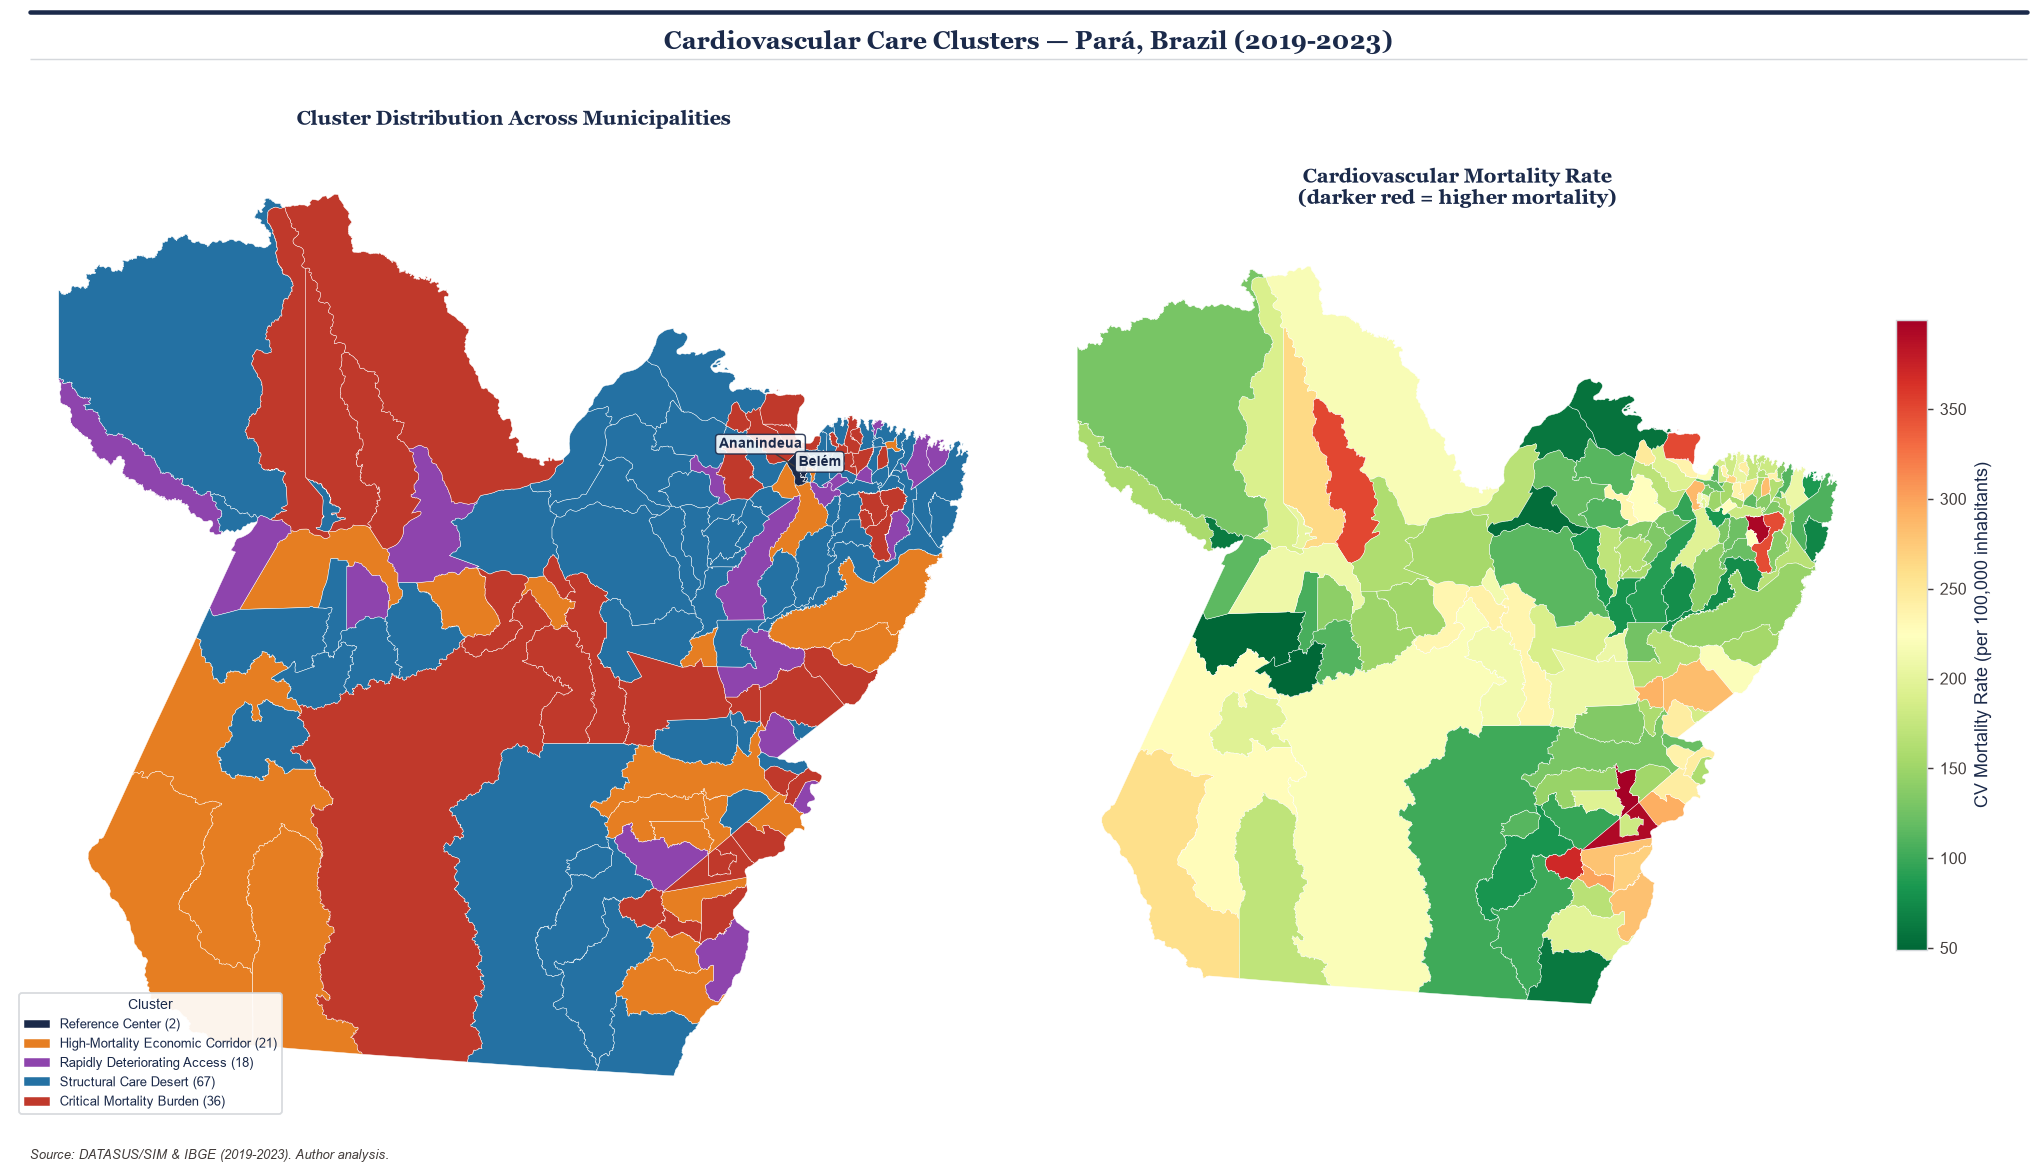

Saved: figures/09_cluster_map.png


In [11]:
# ── SECTION 6 — Map Visualization (k=4) ──────────────────────────────────────

import sys
sys.path.insert(0, '..')
from style import apply_style, add_figure_rule, add_source_note, add_separator, title_font, PALETTE
apply_style()

PATH_SHAPEFILE = '../data/raw/PA_Municipios_2022.shp'
mapa = gpd.read_file(PATH_SHAPEFILE)
mapa['CD_MUN'] = mapa['CD_MUN'].astype(str).str[:6]

mapa_c = mapa.merge(
    df[['cod_ibge','cluster','cluster_label','taxa_mort_100k','taxa_proc_100k']],
    left_on='CD_MUN', right_on='cod_ibge', how='left'
)

matched   = mapa_c['cluster'].notna().sum()
unmatched = mapa_c['cluster'].isna().sum()
print(f'Matched   : {matched}')
print(f'Unmatched : {unmatched}')

# ── Color and label maps — k=4 + reference centers ───────────────────────────
CLUSTER_COLORS_MAP = {
    -1: '#1B2A4A',   # navy    — reference centers
     0: '#E67E22',   # orange  — high-mortality economic corridor
     1: '#8E44AD',   # purple  — rapidly deteriorating
     2: '#2471A3',   # steel   — structural care desert
     3: '#C0392B',   # crimson — critical mortality burden (highest = most alarming)
}

CLUSTER_LABELS_MAP = {
    -1: 'Reference Center (2)',
     0: 'High-Mortality Economic Corridor (21)',
     1: 'Rapidly Deteriorating Access (18)',
     2: 'Structural Care Desert (67)',
     3: 'Critical Mortality Burden (36)',
}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 9))
fig.suptitle('Cardiovascular Care Clusters — Pará, Brazil (2019-2023)',
             fontproperties=title_font(14), y=0.98, color=PALETTE['navy'])
add_figure_rule(fig, y=0.995)
add_separator(fig, y=0.955)

ax  = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# ── Left: cluster map ────────────────────────────────────────────────────────
for c in sorted(CLUSTER_COLORS_MAP.keys()):
    sub = mapa_c[mapa_c['cluster'] == c]
    if len(sub) == 0:
        continue
    sub.plot(ax=ax, color=CLUSTER_COLORS_MAP[c],
             edgecolor='white', linewidth=0.25,
             label=CLUSTER_LABELS_MAP[c])

# Reference center borders + labels
ref = mapa_c[mapa_c['cluster'] == -1]
ref.plot(ax=ax, color=CLUSTER_COLORS_MAP[-1],
         edgecolor='white', linewidth=0.25)

label_offsets = {
    'BELEM':      ( 0.8, -0.3),
    'ANANINDEUA': (-1.2,  0.35),
}
for _, row in ref.iterrows():
    name = row['NM_MUN'].upper()
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    dx, dy = label_offsets.get(name, (0, 0))
    ax.annotate(
        row['NM_MUN'].title(),
        xy=(cx, cy), xytext=(cx + dx, cy + dy),
        fontsize=7.5, fontweight='bold', color=PALETTE['navy'],
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white',
                  edgecolor=PALETTE['navy'], alpha=0.88, linewidth=0.8),
        arrowprops=dict(arrowstyle='-', color=PALETTE['slate'],
                        lw=0.8, shrinkA=0, shrinkB=3)
    )

ax.set_title('Cluster Distribution Across Municipalities',
             fontproperties=title_font(11), pad=14, color=PALETTE['navy'])
ax.axis('off')
ax.legend(loc='lower left', fontsize=7, frameon=True,
          framealpha=0.92, edgecolor=PALETTE['rule'],
          title='Cluster', title_fontsize=8)

# ── Right: mortality choropleth ───────────────────────────────────────────────
mapa_c.plot(
    column='taxa_mort_100k',
    ax=ax2, cmap='RdYlGn_r',
    edgecolor='white', linewidth=0.25,
    legend=True,
    missing_kwds={'color': PALETTE['rule']},
    legend_kwds={
        'label': 'CV Mortality Rate (per 100,000 inhabitants)',
        'orientation': 'vertical',
        'shrink': 0.65, 'pad': 0.02,
    }
)
ax2.set_title('Cardiovascular Mortality Rate\n(darker red = higher mortality)',
              fontproperties=title_font(11), pad=14, color=PALETTE['navy'])
ax2.axis('off')

add_source_note(fig, y=0.015)
plt.tight_layout(rect=[0, 0.03, 1, 0.935])
plt.savefig('figures/09_cluster_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/09_cluster_map.png')

---
## Section 7 - Statistical Validation

**Why validate the clustering:**
Just because K-Means produced groups does not mean the groups are meaningful.
We need to confirm that the clusters are genuinely different from each other
on the variables that matter.

**ANOVA (Analysis of Variance):**
Tests whether the means of a variable are significantly different across groups.
A p-value below 0.05 means we can reject the hypothesis that all cluster means
are equal - i.e., the clusters are genuinely distinct on that variable.

This goes in the manuscript Methods section under "Statistical Analysis".

In [12]:
# ── SECTION 7 — Cluster Validating ───────────────────────────────────────────

from scipy import stats

print('=== ANOVA - ARE CLUSTER MEANS SIGNIFICANTLY DIFFERENT? ===')
print()
print(f'{"Feature":<25} {"F-statistic":>12} {"p-value":>12} {"Significant?":>14}')
print('-' * 65)

for feat in FEATURES_RAW:
    groups = [
        df_cluster[df_cluster['cluster'] == c][feat].values
        for c in sorted(df_cluster['cluster'].unique())
    ]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = 'YES (p<0.05)' if p_val < 0.05 else 'NO'
    print(f'{feat:<25} {f_stat:>12.3f} {p_val:>12.4f} {sig:>14}')

print()
print('Interpretation: significant p-value means cluster means are')
print('statistically distinguishable on that variable.')
print('All significant features = clusters are real, not random groupings.')

=== ANOVA - ARE CLUSTER MEANS SIGNIFICANTLY DIFFERENT? ===

Feature                    F-statistic      p-value   Significant?
-----------------------------------------------------------------
taxa_mort_100k                  53.269       0.0000   YES (p<0.05)
taxa_proc_100k                     nan          nan             NO
pib_per_capita                  12.638       0.0000   YES (p<0.05)
crescimento_mort                24.160       0.0000   YES (p<0.05)

Interpretation: significant p-value means cluster means are
statistically distinguishable on that variable.
All significant features = clusters are real, not random groupings.


---
## Section 8 - Save Results & Final Summary

In [13]:
# ── SECTION 8 — Saving Results ───────────────────────────────────────────────

# Save full dataset with cluster assignments
df.to_csv('../data/processed/para_cardiovascular_clustered.csv', index=False)
print('Saved: data/processed/para_cardiovascular_clustered.csv')

# Save cluster profile summary
profile_out = df.groupby(['cluster','cluster_label'])[FEATURES_RAW].agg(['mean','std']).round(2)
profile_out.to_csv('../data/processed/cluster_profiles.csv')
print('Saved: data/processed/cluster_profiles.csv')

print()
print('=' * 60)
print('CLUSTERING RESULTS SUMMARY')
print('=' * 60)
print(f'Algorithm        : K-Means (k={OPTIMAL_K}, n_init=10, random_state=42)')
print(f'Features used    : {", ".join(FEATURES_RAW)}')
print(f'Normalization    : StandardScaler (mean=0, std=1)')
print(f'Silhouette score : {silhouette_score(X_scaled, df_cluster["cluster"]):.4f}')
print(f'WCSS (inertia)   : {km_final.inertia_:.2f}')
print()
for c in sorted(df_cluster['cluster'].unique()):
    sub = df_cluster[df_cluster['cluster']==c]
    print(f'Cluster {c} - "{CLUSTER_NAMES[c]}" ({len(sub)} municipalities)')
    print(f'  Mortality rate  : {sub["taxa_mort_100k"].mean():.1f} per 100k (mean)')
    print(f'  Procedure rate  : {sub["taxa_proc_100k"].mean():.2f} per 100k (mean)')
    print(f'  GDP per capita  : R${sub["pib_per_capita"].mean():,.0f} (mean)')
    print(f'  Mortality growth: {sub["crescimento_mort"].mean():.1f}% (mean)')
    print()
print('=' * 60)
print('Notebook 03 complete.')
print('All figures saved to notebooks/figures/')
print('Clustered data saved to data/processed/')

Saved: data/processed/para_cardiovascular_clustered.csv
Saved: data/processed/cluster_profiles.csv

CLUSTERING RESULTS SUMMARY
Algorithm        : K-Means (k=4, n_init=10, random_state=42)
Features used    : taxa_mort_100k, taxa_proc_100k, pib_per_capita, crescimento_mort
Normalization    : StandardScaler (mean=0, std=1)
Silhouette score : 0.3054
WCSS (inertia)   : 188.90

Cluster 0 - "High-Mortality Economic Corridor" (21 municipalities)
  Mortality rate  : 203.3 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$693,864 (mean)
  Mortality growth: 26.5% (mean)

Cluster 1 - "Rapidly Deteriorating Access" (18 municipalities)
  Mortality rate  : 159.5 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$129,502 (mean)
  Mortality growth: 295.8% (mean)

Cluster 2 - "Structural Care Desert" (67 municipalities)
  Mortality rate  : 129.8 per 100k (mean)
  Procedure rate  : 0.00 per 100k (mean)
  GDP per capita  : R$117,222 (mean)
  Mortali

---
## Completion Checklist

- [ ] `figures/07_elbow_silhouette.png` saved
- [ ] `figures/08_cluster_profiles.png` saved
- [ ] `figures/09_cluster_map.png` saved - **primary manuscript figure**
- [ ] ANOVA confirms clusters are statistically significant
- [ ] Cluster labels assigned and documented
- [ ] `para_cardiovascular_clustered.csv` saved

**After completing this notebook:**
1. Review the cluster map and profiles
2. Write interpretive names in Section 5 (`CLUSTER_NAMES` dictionary)
3. Re-run Section 5 onward with the named clusters
4. Commit all figures and the clustered dataset
5. Begin manuscript draft

---
*Pipeline complete: 01_data_cleaning -> 02_eda -> 03_clustering*